In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load the Breast Cancer dataset
cancer = load_breast_cancer()

# Create a pandas DataFrame
cancer_df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)

# Add the target variable to the DataFrame
cancer_df['target'] = cancer.target

print(cancer_df.shape)
# Display the first few rows of the DataFrame
cancer_df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Assuming having >= 70% correlation
th = 0.7
high_corr = abs(cancer_df.corr()['target']) >= th

In [3]:
high_corr_keys = [k for k, v in zip(high_corr.keys(), high_corr.values) if abs(v) >= th]
# Get a 2nd dataset from this point
cancer_df_filt = cancer_df[high_corr_keys]
cancer_df_filt.head()

,mean radius,mean perimeter,mean area,mean concave points,worst radius,worst perimeter,worst area,worst concave points,target
0,17.99,122.80,1001.0,0.14710,25.38,184.60,2019.0,0.2654,0
1,20.57,132.90,1326.0,0.07017,24.99,158.80,1956.0,0.1860,0
2,19.69,130.00,1203.0,0.12790,23.57,152.50,1709.0,0.2430,0
3,11.42,77.58,386.1,0.10520,14.91,98.87,567.7,0.2575,0
4,20.29,135.10,1297.0,0.10430,22.54,152.20,1575.0,0.1625,0


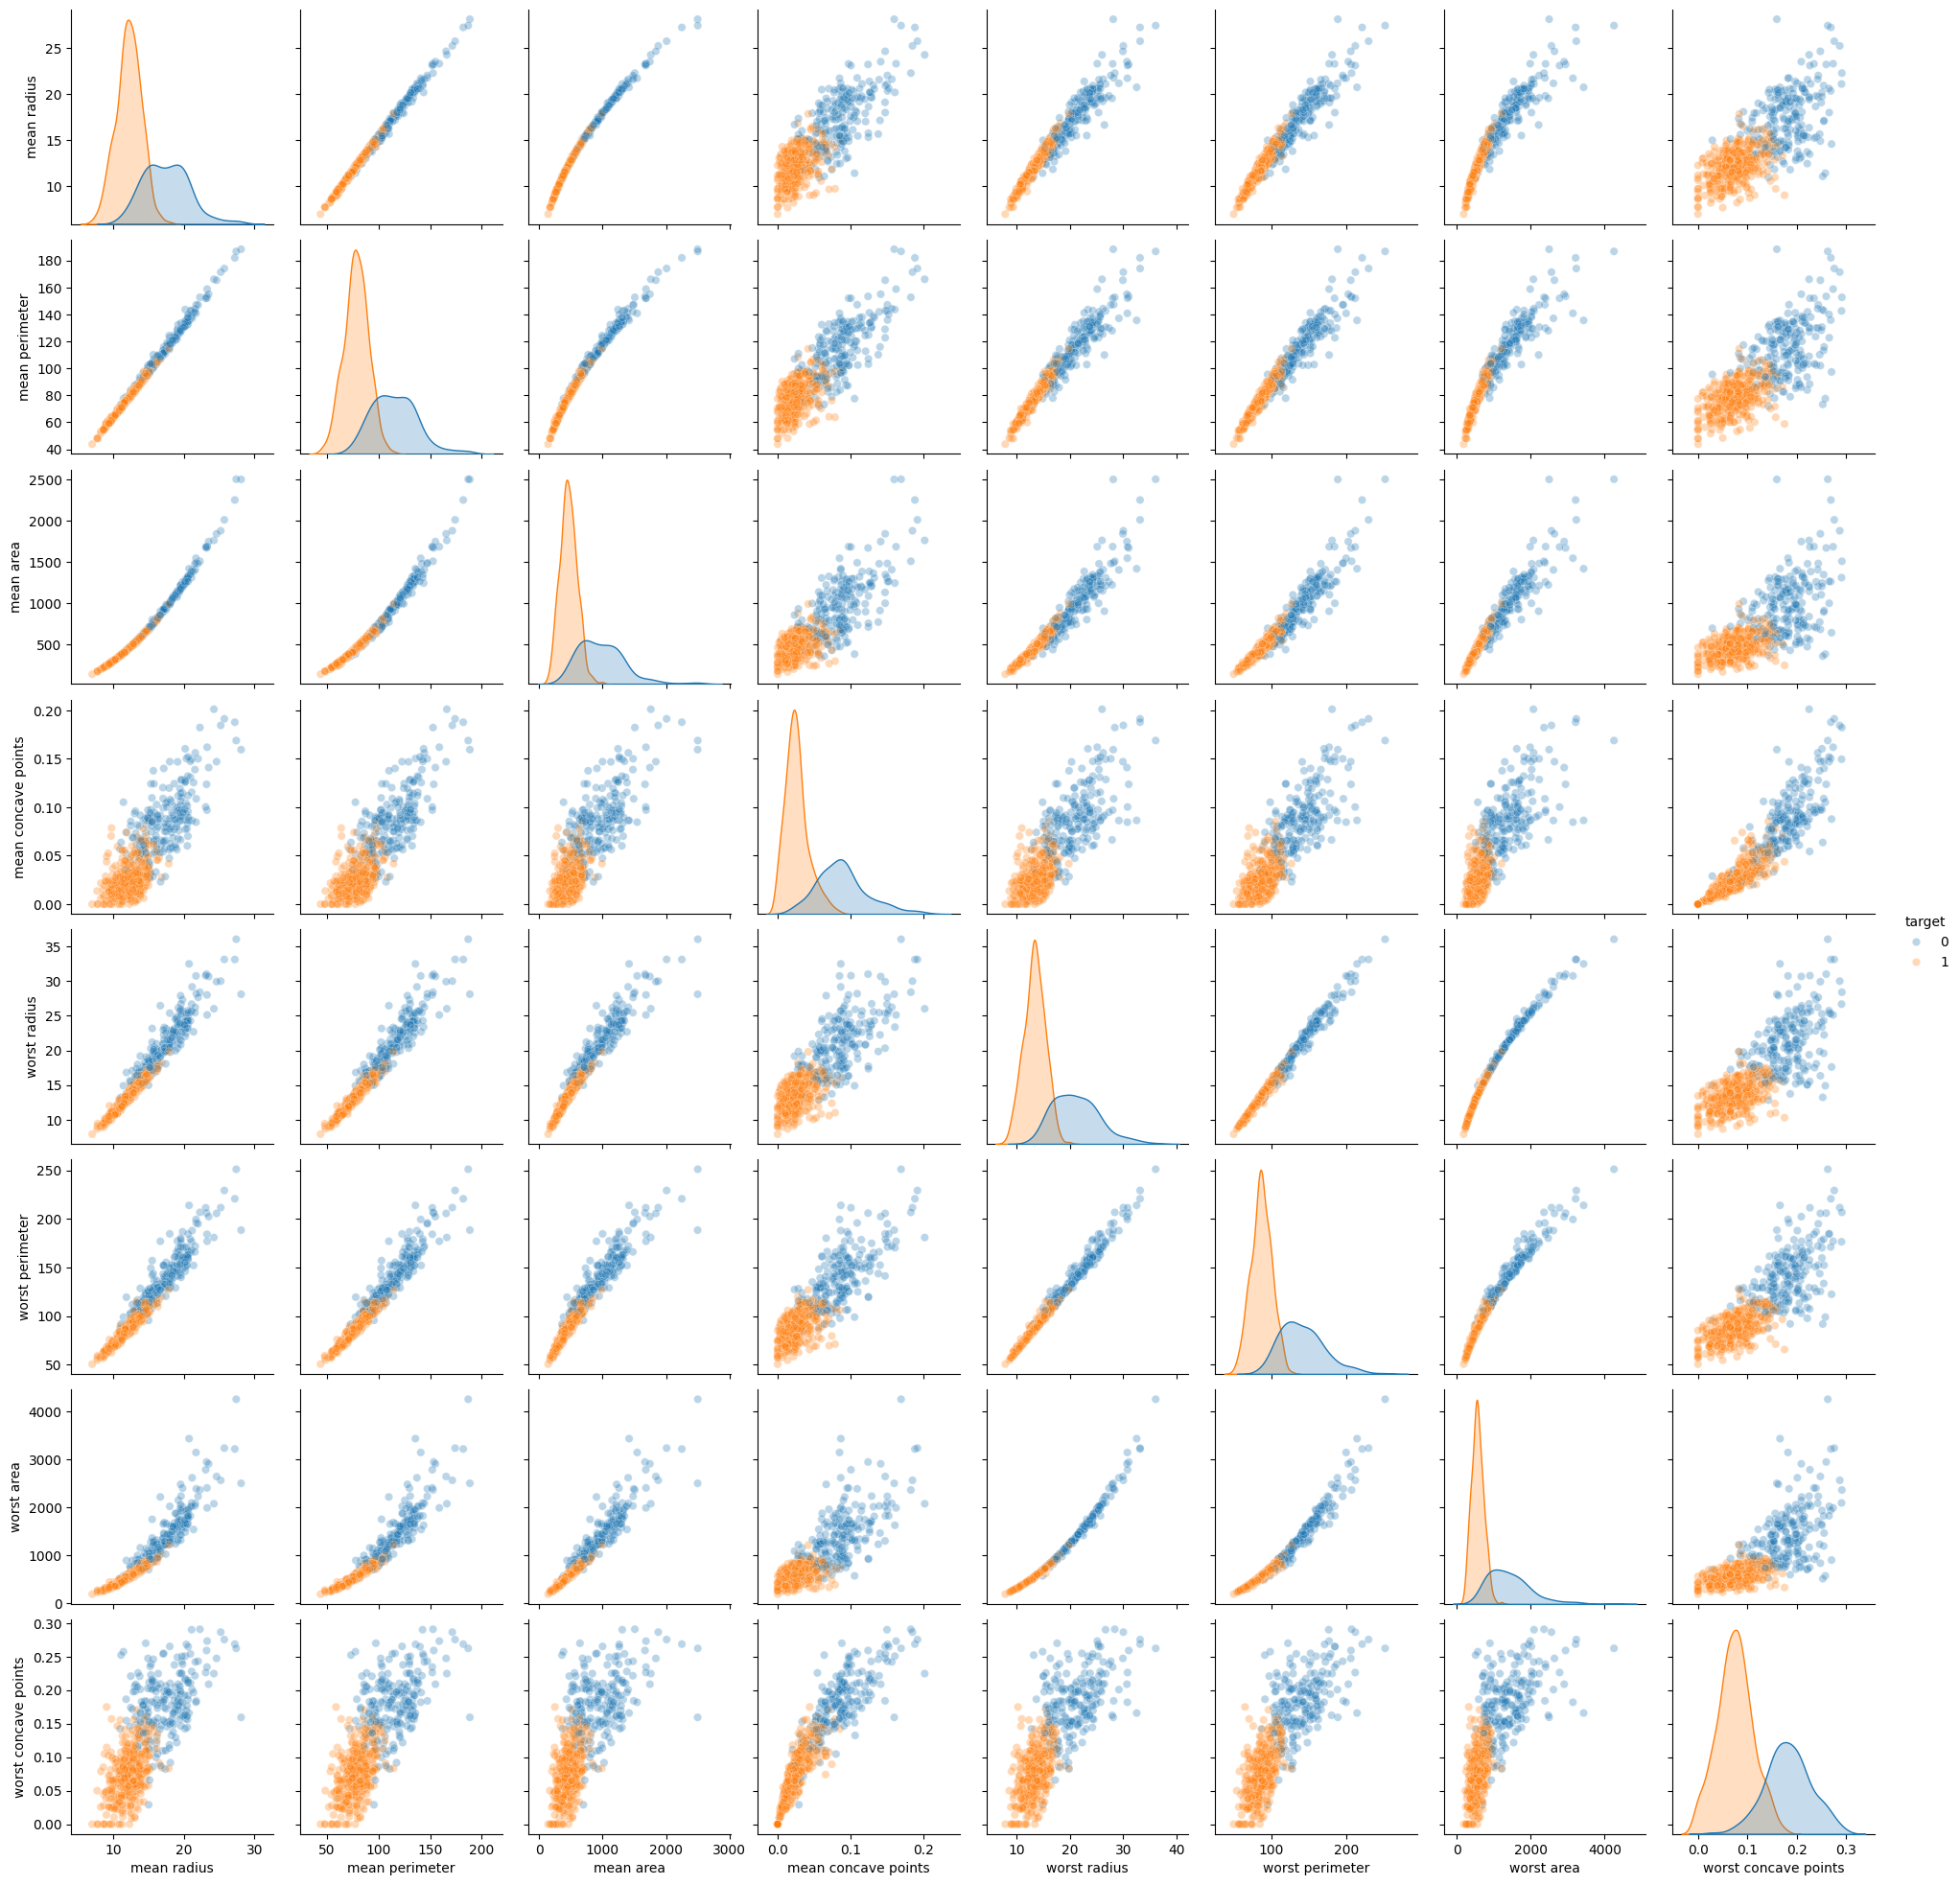

In [4]:
sns.pairplot(cancer_df_filt, hue = 'target', plot_kws={"alpha": 0.3})

Mean squared error: 8640.046940940014
R-squared: 0.9730383976818977


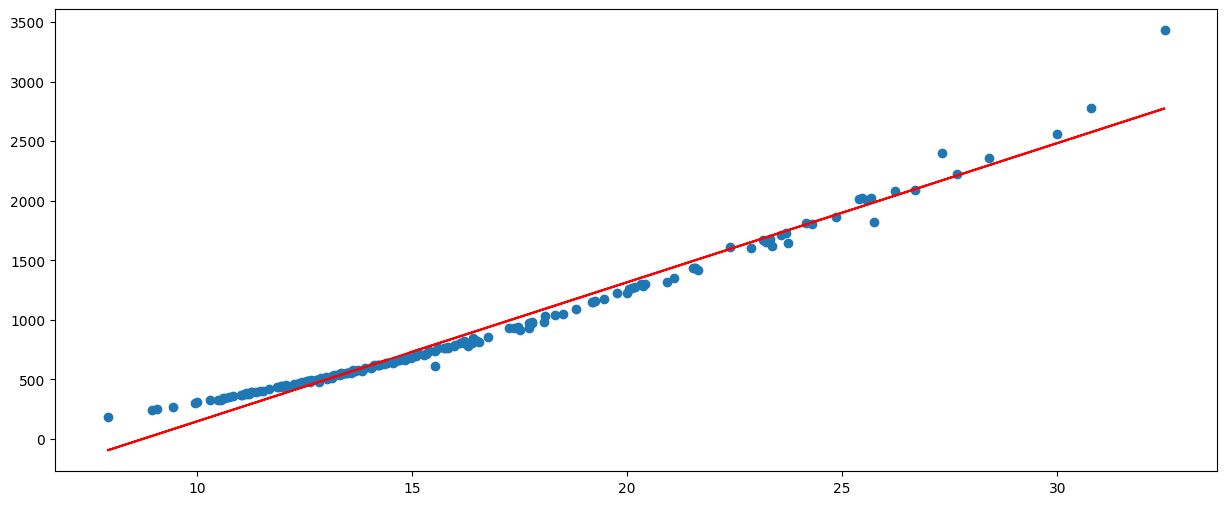

In [5]:
# Vamos a seleccionar las variables, tanto las X como las Y con una única variable independiente
# Regresión Lineal Simple con 'worst radius' como variable independiente y 'worst area' como variable dependiente
X = cancer_df_filt[['worst radius']]
y = cancer_df_filt['worst area']

# Dividir en conjunto de entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Algoritmo
# Regresión Lineal Simple
regressor = LinearRegression()
# Entrenamiento del modelo
regressor.fit(X_train, y_train)

# Predicción y evaluación
y_pred = regressor.predict(X_test)
# Cálculo del error cuadrático medio y R²
# El error cuadrático medio (MSE) mide la diferencia promedio entre los valores predichos y los valores reales.
# R² indica qué tan bien los datos se ajustan al modelo de regresión.
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean squared error:', mse)
print('R-squared:', r2)

plt.figure(figsize = (15, 6))
plt.scatter(X_test, y_test, label = "Testing points")
plt.plot(X_test, y_pred, label = "Predicted points", c = 'r')
plt.show()

In [9]:
from sklearn.preprocessing import PolynomialFeatures

X = cancer_df_filt[['worst radius']]
y = cancer_df_filt['worst area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Polynomial Features + Linear Regression
# La regresión polinómica sigue manteniendo una relación 'lineal' por ello definimos un polinomio de grado 3
# que transforma las características originales en características polinómicas.
# Luego, se ajusta un modelo de regresión lineal a estas características polinómicas.
# Esto permite capturar relaciones no lineales entre las variables independientes y dependientes.
poly = PolynomialFeatures(degree=3)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_train2, y_train)
y_pred2 = poly_model.predict(X_test2)
mse = mean_squared_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)

print('Mean squared error:', mse)
print('R-squared:', r2)


Mean squared error: 1412.796261322269
R-squared: 0.9955913143511084


/mnt/data/MUDS/SBC/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


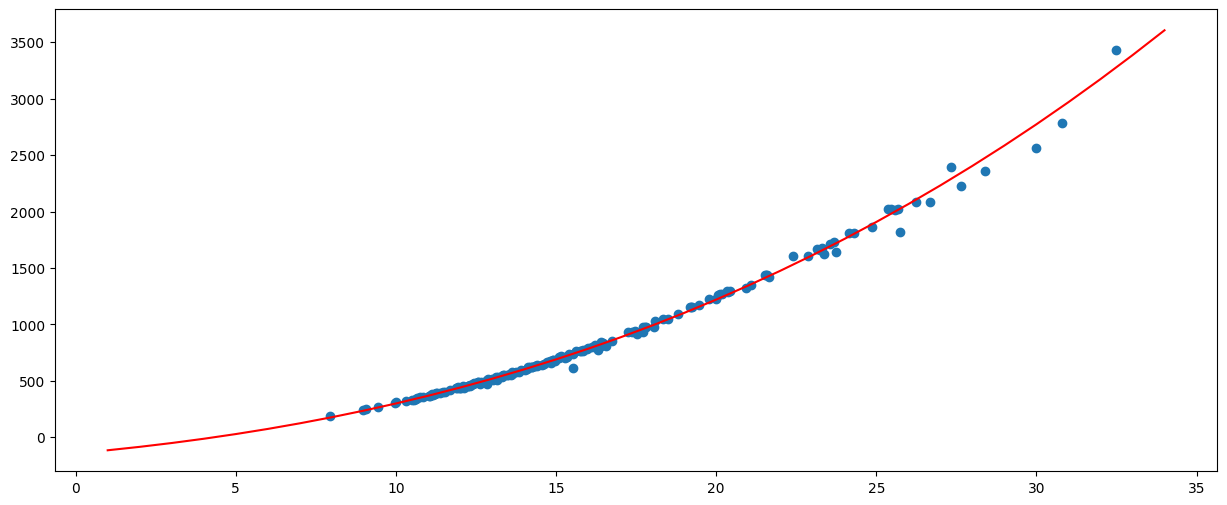

In [7]:
# Visualización de los resultados de la regresión polinómica
# Generamos nuevos puntos de datos para una curva suave de predicción
new_x = np.arange(1, 35).reshape(-1, 1)
new_x2 = poly.transform(new_x)

# Hacemos las predicciones con el modelo polinómico
pred = poly_model.predict(new_x2)

plt.figure(figsize = (15, 6))
plt.scatter(X_test, y_test, label = "Testing points")
plt.plot(new_x, pred, label = "Predicted points", c = 'r')
plt.show()

In [10]:
cancer_df_filt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mean radius           569 non-null    float64
 1   mean perimeter        569 non-null    float64
 2   mean area             569 non-null    float64
 3   mean concave points   569 non-null    float64
 4   worst radius          569 non-null    float64
 5   worst perimeter       569 non-null    float64
 6   worst area            569 non-null    float64
 7   worst concave points  569 non-null    float64
 8   target                569 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 40.1 KB


Decision Tree Regressor (max_depth=2) - Mean squared error: 35454.0111494844
Decision Tree Regressor (max_depth=2) - R-squared: 0.8893643801094948
Decision Tree Regressor (max_depth=5) - Mean squared error: 2186.9076218225086
Decision Tree Regressor (max_depth=5) - R-squared: 0.9931756697609342


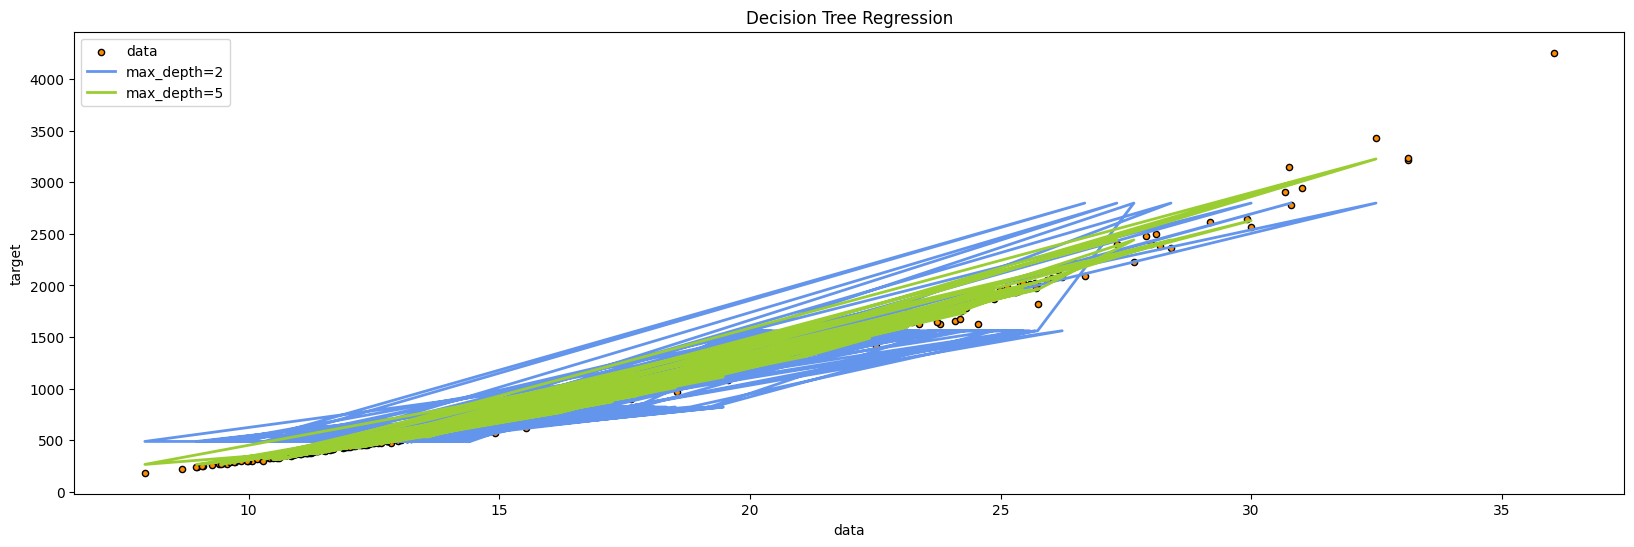

In [11]:
from sklearn.tree import DecisionTreeRegressor

X = cancer_df_filt[['worst radius']]
y = cancer_df_filt['worst area']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Decision Tree Regressor

# Creamos dos modelos de regresión de árbol de decisión con diferentes profundidades máximas (max_depth) para comparar su rendimiento.
regressor_1 = DecisionTreeRegressor(max_depth=2)
regressor_1.fit(X_train, y_train)
y_1 = regressor_1.predict(X_test)
regressor_2 = DecisionTreeRegressor(max_depth=5)
regressor_2.fit(X_train, y_train)
y_2 = regressor_2.predict(X_test)
mse_1 = mean_squared_error(y_test, y_1)
r2_1 = r2_score(y_test, y_1)
mse_2 = mean_squared_error(y_test, y_2)
r2_2 = r2_score(y_test, y_2)

print('Decision Tree Regressor (max_depth=2) - Mean squared error:', mse_1)
print('Decision Tree Regressor (max_depth=2) - R-squared:', r2_1)
print('Decision Tree Regressor (max_depth=5) - Mean squared error:', mse_2)
print('Decision Tree Regressor (max_depth=5) - R-squared:', r2_2)

plt.figure(figsize = (20, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()